1. IMPORT DATA LIBRARY

In [32]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
from google.colab import files

uploaded = files.upload()

Saving car_prices.csv to car_prices.csv


In [38]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

2. LOAD DATASET

In [4]:
df = pd.read_csv('/content/car_prices.csv')

In [5]:
print(df.head())

   year   make                model        trim   body transmission  \
0  2015    Kia              Sorento          LX    SUV    automatic   
1  2015    Kia              Sorento          LX    SUV    automatic   
2  2014    BMW             3 Series  328i SULEV  Sedan    automatic   
3  2015  Volvo                  S60          T5  Sedan    automatic   
4  2014    BMW  6 Series Gran Coupe        650i  Sedan    automatic   

                 vin state  condition  odometer  color interior  \
0  5xyktca69fg566472    ca        5.0   16639.0  white    black   
1  5xyktca69fg561319    ca        5.0    9393.0  white    beige   
2  wba3c1c51ek116351    ca       45.0    1331.0   gray    black   
3  yv1612tb4f1310987    ca       41.0   14282.0  white    black   
4  wba6b2c57ed129731    ca       43.0    2641.0   gray    black   

                                   seller      mmr  sellingprice  \
0                 kia motors america  inc  20500.0       21500.0   
1                 kia motors ameri

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB
None


3. PREPROCESSING

3.1 Check Missing Value

In [7]:
df = df.dropna()

In [22]:
(df.isnull().sum()/len(df)*100).sort_values(ascending=False)

,0
year,0.0
make,0.0
model,0.0
trim,0.0
body,0.0
transmission,0.0
vin,0.0
state,0.0
condition,0.0
odometer,0.0


3.2 Check Duplicate Data

In [23]:
df.duplicated().sum()

np.int64(0)

3.3 Menghapus Kolom yang tidak Digunakan

In [24]:
df = df.dropna(subset=["sellingprice"])
df = df.drop(columns=["vin","saledate"], errors='ignore')

3.3 Menentukan Target

In [25]:
target = 'sellingprice'

3.4 Encoding Data Kategorikal

---



In [26]:
label = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = label.fit_transform(df[col].astype(str))

3.5 Memisahkan Fitur dan Target

In [27]:
X = df.drop(target, axis=1)
y = df[target]

3.6 Split Data

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

3.7 Memisahkan Kolom Numerik dan Kategorikal

In [30]:
numeric_features = X.select_dtypes(include=["int64","float64"]).columns

categorical_features = X.select_dtypes(include=["object"]).columns

3.8 Pipeline Preprocessing

In [34]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [39]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [40]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

4. EXPLORATORY DATA ANALYSIS (EDA)

4.1 Statistik Deskripsi

In [41]:
df.describe()

,year,make,model,trim,body,transmission,state,condition,odometer,color,interior,seller,mmr,sellingprice
count,472325.000000,472325.000000,472325.000000,472325.000000,472325.000000,472325.000000,472325.000000,472325.000000,472325.000000,472325.000000,472325.000000,472325.000000,472325.000000,472325.000000
mean,2010.210980,21.690139,336.265485,772.906264,39.229924,0.034641,13.721643,30.774177,66701.732040,9.429154,3.884806,5992.753153,13837.058964,13690.512058
std,3.822151,14.324609,210.158696,377.491734,17.556724,0.182870,10.440314,13.286866,51939.586894,6.654012,4.102985,3434.348998,9532.229273,9613.033738
min,1990.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,25.000000,1.000000
25%,2008.000000,10.000000,171.000000,419.000000,35.000000,0.000000,4.000000,24.000000,28137.000000,2.000000,1.000000,3506.000000,7425.000000,7200.000000
50%,2012.000000,18.000000,288.000000,808.000000,36.000000,0.000000,12.000000,35.000000,51085.000000,7.000000,1.000000,5472.000000,12300.000000,12200.000000
75%,2013.000000,34.000000,492.000000,1044.000000,36.000000,0.000000,25.000000,41.000000,96590.000000,15.000000,6.000000,9025.000000,18300.000000,18200.000000
max,2015.000000,52.000000,767.000000,1493.000000,84.000000,1.000000,33.000000,49.000000,999999.000000,19.000000,16.000000,11922.000000,182000.000000,230000.000000


4.2 Distribusi Harga Mobil

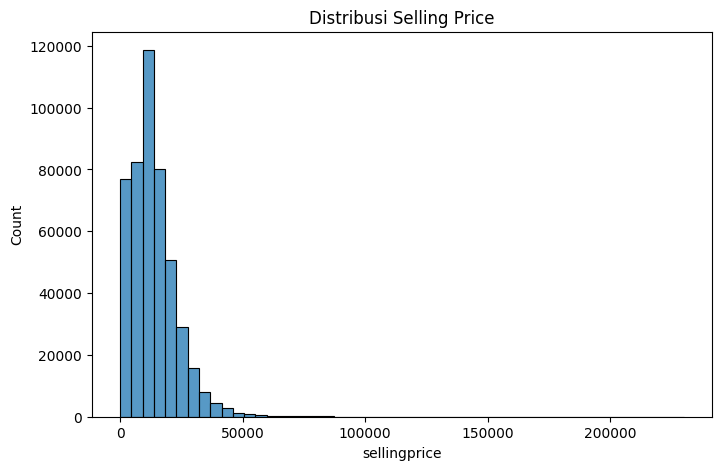

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df["sellingprice"], bins=50)
plt.title("Distribusi Selling Price")
plt.show()

4.3 Distribusi Odometer

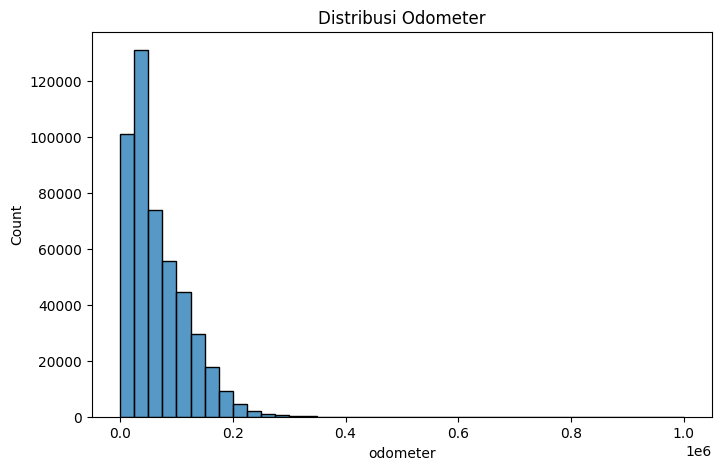

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df["odometer"], bins=40)
plt.title("Distribusi Odometer")
plt.show()

4.4 Korelasi Antar Variabel Numerik

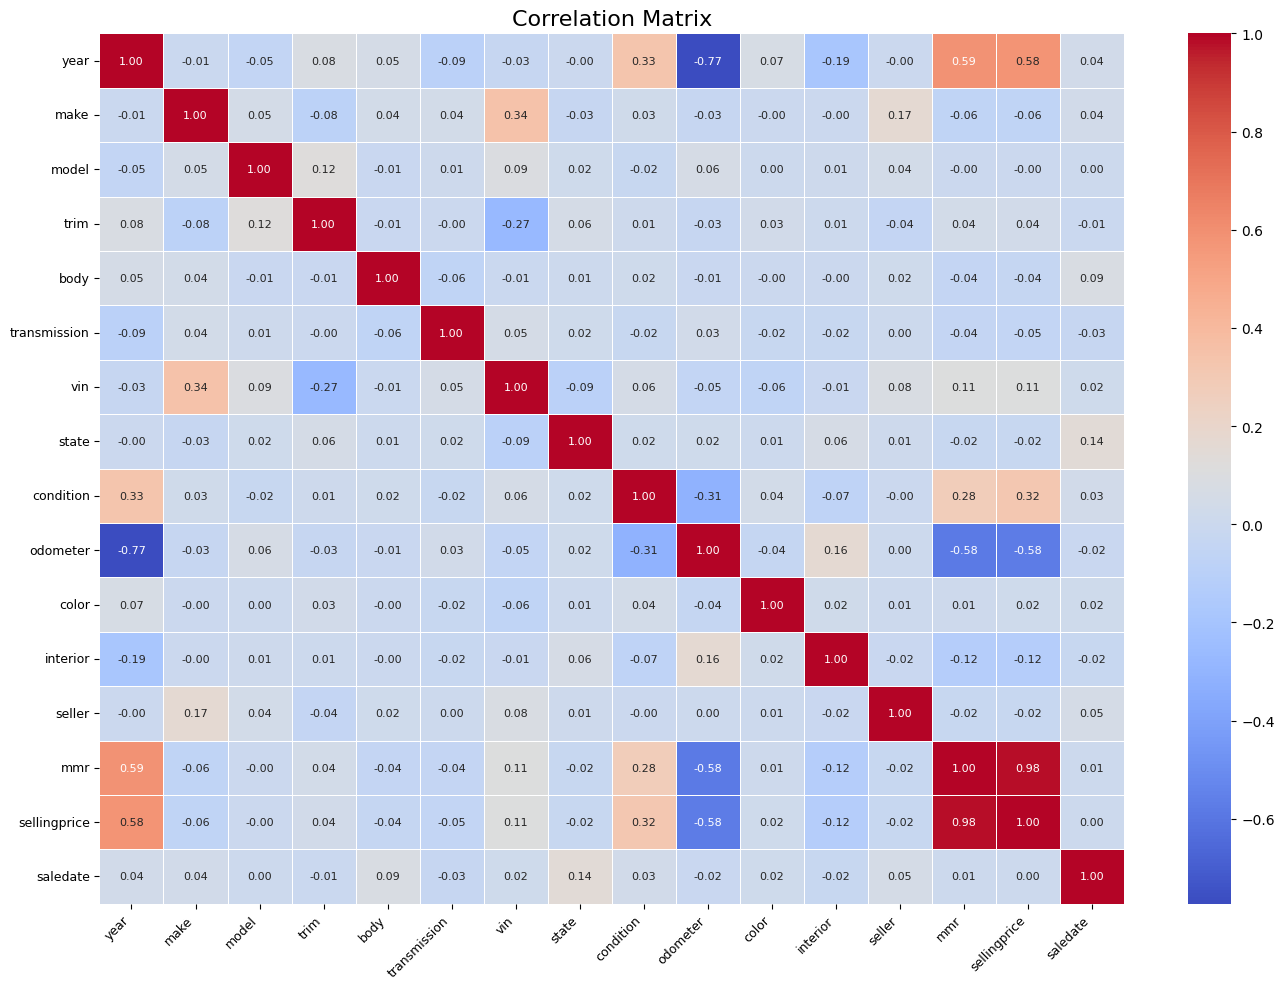

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(14,10))   # Perbesar ukuran gambar

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    fmt=".2f",              # Menampilkan 2 angka di belakang koma
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size":8}    # Ukuran angka
)

plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

4.5 Harga Mobil Berdasarkan Tahun

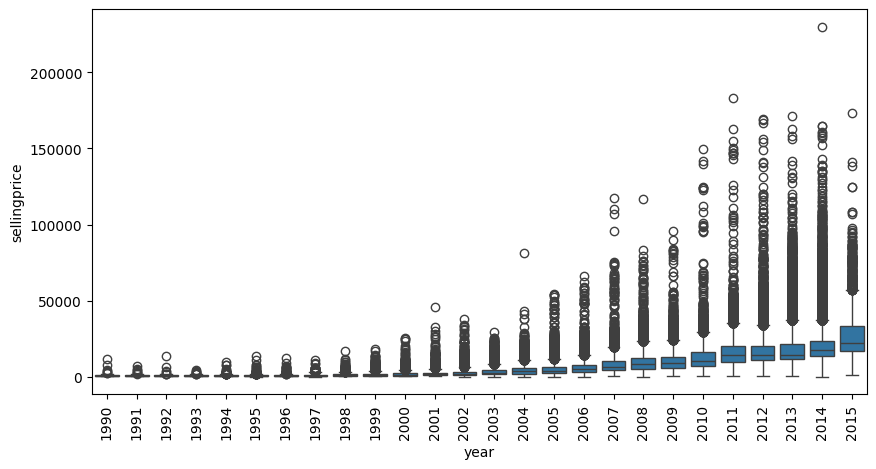

In [20]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="year",
    y="sellingprice",
    data=df
)

plt.xticks(rotation=90)

plt.show()

5. MODELLING MENGGUNAKAN LINEAR REGRESSION

In [ ]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("===== LINEAR REGRESSION =====")
print("MAE :", mean_absolute_error(y_test, pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lr)))
print("R2  :", r2_score(y_test, pred_lr))

===== LINEAR REGRESSION =====
MAE : 1038.605487175401
RMSE: 1620.5135940341365
R2  : 0.9711072129037794


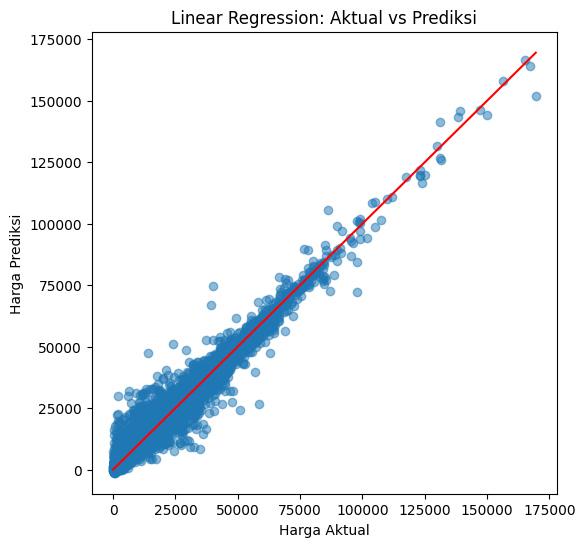

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_lr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Harga Aktual")
plt.ylabel("Harga Prediksi")
plt.title("Linear Regression: Aktual vs Prediksi")
plt.show()

6. MODELLING MENGGUNAKAN RANDOM FOREST REGRESSION

In [ ]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("\n===== RANDOM FOREST REGRESSION =====")
print("MAE :", mean_absolute_error(y_test, pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))
print("R2  :", r2_score(y_test, pred_rf))


===== RANDOM FOREST REGRESSION =====
MAE : 918.8771979039855
RMSE: 1522.032298276469
R2  : 0.974512231303514


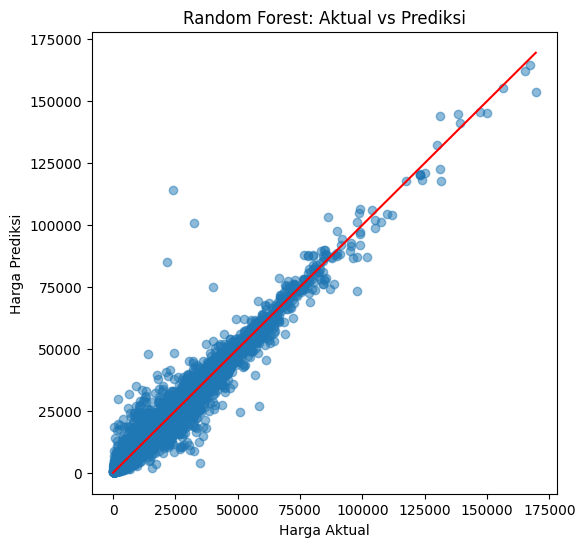

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Harga Aktual")
plt.ylabel("Harga Prediksi")
plt.title("Random Forest: Aktual vs Prediksi")
plt.show()

7. PERBANDINGAN PERFORMA MODEL

In [ ]:
hasil = pd.DataFrame({
    'Model':['Linear Regression','Random Forest'],
    'MAE':[
        mean_absolute_error(y_test,pred_lr),
        mean_absolute_error(y_test,pred_rf)
    ],
    'RMSE':[
        np.sqrt(mean_squared_error(y_test,pred_lr)),
        np.sqrt(mean_squared_error(y_test,pred_rf))
    ],
    'R2 Score':[
        r2_score(y_test,pred_lr),
        r2_score(y_test,pred_rf)
    ]
})

print("\nPerbandingan Model")
print(hasil)


Perbandingan Model
               Model          MAE         RMSE  R2 Score
0  Linear Regression  1038.605487  1620.513594  0.971107
1      Random Forest   918.877198  1522.032298  0.974512


8. Perbandingan Model Linear Regression dan Random Forest Regression

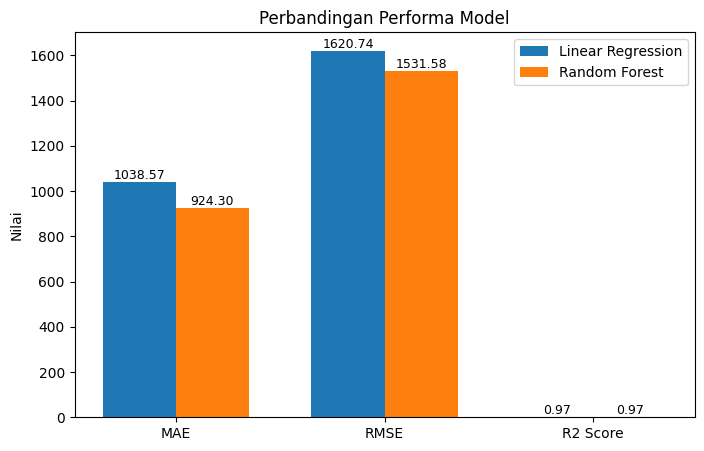

In [56]:
import matplotlib.pyplot as plt

metrics = ['MAE', 'RMSE', 'R2 Score']

lr_values = [
    mean_absolute_error(y_test, pred_lr),
    np.sqrt(mean_squared_error(y_test, pred_lr)),
    r2_score(y_test, pred_lr)

]

rf_values = [
    mean_absolute_error(y_test, pred_rf),
    np.sqrt(mean_squared_error(y_test, pred_rf)),
                        r2_score(y_test, pred_rf)

]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x-width/2, lr_values, width, label='Linear Regression')
plt.bar(x+width/2, rf_values, width, label='Random Forest')
for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x()+bar.get_width()/2,
            bar.get_height(),
            f'{bar.get_height():.2f}',
            ha='center',
            va='bottom',
            fontsize=9
        )
plt.xticks(x, metrics)
plt.ylabel("Nilai")
plt.title("Perbandingan Performa Model")
plt.legend()
plt.show()


9. Jalankan Metode Random Forest untuk mendapatkan Prediksi Harga Mobil

In [65]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'mmr'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index([], dtype='object'))])),
                ('model', RandomForestRegressor(random_state=42))])

In [67]:
new_car = pd.DataFrame({
    "year": [2020],
    "make": ["Toyota"],
    "model": ["Corolla"],
    "trim": ["LE"],
    "body": ["Sedan"],
    "transmission": ["automatic"],
    "state": ["ca"],
    "condition": [42],
    "odometer": [35000],
    "color": ["white"],
    "interior": ["black"],
    "seller": ["Dealer"],
    "mmr": [18500]
})

In [68]:
new_car_encoded = new_car.copy()

for col in new_car_encoded.columns:
    if new_car_encoded[col].dtype == "object":
        try:
            new_car_encoded[col] = label.fit_transform(new_car_encoded[col])
        except:
            pass

In [69]:
prediksi = rf.predict(new_car_encoded)

print("="*50)
print("HASIL PREDIKSI HARGA MOBIL")
print("="*50)

print(new_car)

print("\nPrediksi Harga Jual : ${:,.2f}".format(prediksi[0]))

HASIL PREDIKSI HARGA MOBIL
   year    make    model trim   body transmission state  condition  odometer  \
0  2020  Toyota  Corolla   LE  Sedan    automatic    ca         42     35000   

   color interior  seller    mmr  
0  white    black  Dealer  18500  

Prediksi Harga Jual : $19,128.50
